# Baseline LiDAR model on nuScenes

## Goal

This notebook documents the setup of a baseline LiDAR-only 3D object detector on nuScenes using MMDetection3D.

The objective is to train a clean baseline model that can later be compared against more advanced approaches such as fusion models.

## Experimental setting

The baseline is trained on:
- the nuScenes dataset prepared in the previous notebook
- a reproducible 20% training-scene subset
- the standard validation split

## Why this baseline matters

A LiDAR-only baseline is important because:
- it provides a reference point for later comparisons
- it establishes whether the training pipeline is working correctly
- it helps separate baseline performance from improvements due to fusion or other methods

## Planned outcome

This notebook should:
1. verify the MMDetection3D environment
2. identify the baseline config to use
3. confirm the subset annotation file paths
4. create a baseline training config for the reduced dataset
5. document the training command
6. prepare the experiment for reproducible execution

# Import

In [1]:
# Core libraries
import pandas as pd
import shutil
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List, Tuple, Dict, Final
from pprint import pprint


# OpenMMLab stack
import mmengine
import mmdet
import mmdet3d

In [2]:
# Notebook display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
import torch

if torch.cuda.is_available():
    print("GPU available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Running on CPU


# Setup and environment
## Define project paths
This notebook uses the same project and dataset paths as the dataset-preparation notebook.

I define them explicitly here so that the notebook is self-contained and can be run independently.

In [4]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
MMDET3D_ROOT: Final[Path] = PROJECT_ROOT / "external" / "mmdetection3d"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MMDET3D_ROOT :", MMDET3D_ROOT)

PROJECT_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
MMDET3D_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d


## Verify software environment
Before configuring the baseline model, I verify that:
- MMDetection3D is accessible
- the correct Python environment is active
- core libraries are properly installed

This ensures that training will run without unexpected environment issues.

In [5]:
print("mmengine version:", mmengine.__version__)
print("mmdet version   :", mmdet.__version__)
print("mmdet3d version :", mmdet3d.__version__)

mmengine version: 0.10.7
mmdet version   : 3.2.0
mmdet3d version : 1.4.0


The MMDetection3D environment is correctly set up.

Library versions:
- mmengine: 0.10.7
- mmdet: 3.2.0
- mmdet3d: 1.4.0

These versions are compatible and confirm that the training pipeline can be executed.

## Select the model
For the LiDAR baseline, I use the **CenterPoint** detector, which is a standard and strong baseline for nuScenes 3D object detection.

**Why CenterPoint**
- widely used benchmark model for nuScenes
- strong performance with LiDAR-only input
- fully supported in MMDetection3D

**Configuration choice**

I use the official MMDetection3D config:

`centerpoint_voxel01_second_secfpn_nus.py`

This config defines:
- voxelization-based LiDAR processing
- SECOND backbone
- SECFPN neck
- CenterPoint detection head


## Detection Benchmark Class Mapping

The raw nuScenes annotations use a fine-grained taxonomy containing detailed categories such as:

- `vehicle.bus.bendy`
- `vehicle.bus.rigid`
- `human.pedestrian.adult`
- `human.pedestrian.child`

For 3D detection training and evaluation, MMDetection3D remaps these categories into the 10 official nuScenes detection classes:

```python
[
    "car",
    "truck",
    "construction_vehicle",
    "bus",
    "trailer",
    "barrier",
    "motorcycle",
    "bicycle",
    "pedestrian",
    "traffic_cone",
]
```

Examples:
- `vehicle.bus.bendy` → `bus`
- `vehicle.bus.rigid` → `bus`
- `human.pedestrian.adult` → `pedestrian`
- `human.pedestrian.child` → `pedestrian`

Some categories such as `animal` or `static_object.bicycle_rack` are excluded from the detection benchmark.

This remapping is implemented in the MMDetection3D nuScenes conversion utilities.

# Experiment definition

The default training schedule runs for 20 epochs with periodic validation during training. In practice, this results in a runtime of up to 11 days on a single H100 GPU.

To make experimentation feasible, I use a reduced 20% subset of the dataset and adopt a lighter training schedule to:
- reduce wall-clock training time
- allow multiple experiments (baseline, fusion, ablations)
- still obtain meaningful results

This configuration is suitable for:
- debugging the pipeline
- obtaining a first baseline result quickly
- scaling up later if needed


## Define the goal of this experiment

The goal of this experiment is to train a strong **LiDAR-only baseline** on nuScenes. This baseline will serve as a reference for comparison with fusion models and other improvements.

## Config file

In [6]:
# Main experiment parameters

MODEL_KEY: str = "centerpoint"
SUBSET_LABEL: str = "20pct"
RUN_NAME: str = "run1"

MAX_EPOCHS: int = 10

GPU_TYPE: str = "rtx4090"

SLURM_QOS: str = "job_gpu_preemptable"
SLURM_TIME: str = "06:00:00"
SLURM_MEMORY: str = "48G"

TRAIN_BATCH_SIZE: int = 4
TRAIN_NUM_WORKERS: int = 16

In [7]:
CONFIG: Dict[str, object] = {

    # Experiment
    "experiment_name":
        f"{MODEL_KEY}_nuscenes_{SUBSET_LABEL}_{MAX_EPOCHS}ep_{RUN_NAME}",

    # Model
    "model_name": f"{MODEL_KEY}",

    "base_model_config":
        "centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py",

    "experiment_config_file":
        f"{MODEL_KEY}_nuscenes_{SUBSET_LABEL}.py",

    # Dataset
    "subset_label": SUBSET_LABEL,

    "train_ann_file":
        f"subsets/nuscenes_infos_train_{SUBSET_LABEL}.pkl",

    # Training
    "max_epochs": MAX_EPOCHS,
    "val_interval": 1,

    # Dataloader
    "train_batch_size": TRAIN_BATCH_SIZE,
    "train_num_workers": TRAIN_NUM_WORKERS,

    # Hardware
    "gpu_type": GPU_TYPE,

    # SLURM
    "slurm_dir":
        f"{MODEL_KEY}_{SUBSET_LABEL}",

    "slurm_time": SLURM_TIME,
    "slurm_memory": SLURM_MEMORY,
}

pprint(CONFIG)

{'base_model_config': 'centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py',
 'experiment_config_file': 'centerpoint_nuscenes_20pct.py',
 'experiment_name': 'centerpoint_nuscenes_20pct_10ep_run1',
 'gpu_type': 'rtx4090',
 'max_epochs': 10,
 'model_name': 'centerpoint',
 'slurm_dir': 'centerpoint_20pct',
 'slurm_memory': '48G',
 'slurm_time': '06:00:00',
 'subset_label': '20pct',
 'train_ann_file': 'subsets/nuscenes_infos_train_20pct.pkl',
 'train_batch_size': 4,
 'train_num_workers': 16,
 'val_interval': 1}


In [8]:
# Change only this name for each independent training run.
# A new experiment folder, checkpoints, logs, and vis_data
# will automatically be created from this name.
EXPERIMENT_NAME: Final[str] = CONFIG["experiment_name"]

print("EXPERIMENT_NAME:", EXPERIMENT_NAME)

EXPERIMENT_NAME: centerpoint_nuscenes_20pct_10ep_run1


## Select the model

I use **CenterPoint** as the baseline detector. It is a widely used and strong LiDAR-based model for nuScenes.

**Rationale**

- standard benchmark model
- strong LiDAR-only performance
- fully supported in MMDetection3D

In [9]:
MODEL_NAME: Final[str]  = CONFIG["model_name"]
BASE_MODEL_CONFIG: Final[str]  = CONFIG["base_model_config"]

print("MODEL_NAME       :", MODEL_NAME)
print("MBASE_MODEL_CONFIG:", BASE_MODEL_CONFIG)

MODEL_NAME       : centerpoint
MBASE_MODEL_CONFIG: centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py


![](https://user-images.githubusercontent.com/30491025/143854976-11af75ae-e828-43ad-835d-ac1146f99925.png)
[Center-based 3D Object Detection and Tracking](https://arxiv.org/abs/2006.11275)

* **Left:** raw LiDAR point cloud acquired around the ego vehicle
* **3D Backbone:** voxelizes the sparse point cloud, extracts 3D voxel features and flattens them into a Bird’s-Eye View (BEV) feature map
* **Colored feature blocks:** learned BEV spatial features generated from the voxelized LiDAR representation
* **Head:** predicts object centers directly on the BEV map
* **Blue boxes with red center dots:** detected object centers and corresponding 3D bounding boxes
* **Arrows toward MLP:** optional second-stage refinement using additional point features sampled around the predicted box
* **MLP outputs:** refined confidence score and refined 3D bounding box prediction


## Define the configuration path

I create a separate experiment config instead of modifying the original MMDetection3D config directly. This keeps the repository clean and makes the experiment easier to reproduce.



In [10]:
SOURCE_CONFIG_PATH: Path = (
    MMDET3D_ROOT
    / "configs"
    / CONFIG["model_name"]
    / CONFIG["base_model_config"]
)

EXPERIMENT_CONFIG_DIR: Path = MMDET3D_ROOT / "configs" / "my_experiments"
EXPERIMENT_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG_PATH: Path = EXPERIMENT_CONFIG_DIR / CONFIG["experiment_config_file"]

print("SOURCE_CONFIG_PATH     :", SOURCE_CONFIG_PATH)
print("SOURCE exists          :", SOURCE_CONFIG_PATH.exists())
print("EXPERIMENT_CONFIG_DIR  :", EXPERIMENT_CONFIG_DIR)
print("EXPERIMENT_CONFIG_PATH :", EXPERIMENT_CONFIG_PATH)

SOURCE_CONFIG_PATH     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/centerpoint/centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py
SOURCE exists          : True
EXPERIMENT_CONFIG_DIR  : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments
EXPERIMENT_CONFIG_PATH : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/centerpoint_nuscenes_20pct.py


## Copy the baseline config into the experiment folder

I now create a project-specific copy of the baseline CenterPoint config.

This copied config will be the one modified for the reduced dataset experiment.
The original MMDetection3D config remains untouched.

In [11]:
if EXPERIMENT_CONFIG_PATH.exists():
    print("EXPERIMENT_CONFIG_PATH:", EXPERIMENT_CONFIG_PATH)
    print("\nSafety rule: existing file is not overwritten automatically.")
else:
    shutil.copy2(SOURCE_CONFIG_PATH, EXPERIMENT_CONFIG_PATH)
    print("Copied source config to:")
    print(EXPERIMENT_CONFIG_PATH)

print("\nExperiment config exists:", EXPERIMENT_CONFIG_PATH.exists())

EXPERIMENT_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/centerpoint_nuscenes_20pct.py

Safety rule: existing file is not overwritten automatically.

Experiment config exists: True


## Config file settings

In this section, I prepare and modify the MMDetection3D config file for the LiDAR-only baseline experiment. All key settings, including the dataset, model, training schedule, and data loading parameters, are defined through this configuration.

The main modifications introduce a reduced-budget training setup using a reproducible 20% subset of the nuScenes training data, a shorter training schedule, and adjusted data-loading settings. These changes reduce computational cost while keeping the experiment suitable for analysis and comparison.

The configuration is based on the official CenterPoint LiDAR-only nuScenes setup:

- `MODEL_NAME`: `CenterPoint`
- `BASE_MODEL_CONFIG`: `centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py`

This LiDAR-only model serves as the baseline reference for comparison with the BEVFusion LiDAR-camera model under the same reduced-data training conditions.

## Open the config file

In [74]:
# Read the original MMDetection3D configuration file and print it with line numbers for easier inspection.
with open(SOURCE_CONFIG_PATH, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    print(f"{i+1:03d}: {line.rstrip()}")

001: _base_ = [
002:     '../_base_/datasets/nus-3d.py',
003:     '../_base_/models/centerpoint_voxel01_second_secfpn_nus.py',
004:     '../_base_/schedules/cyclic-20e.py', '../_base_/default_runtime.py'
005: ]
006: 
007: # If point cloud range is changed, the models should also change their point
008: # cloud range accordingly
009: point_cloud_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
010: # Using calibration info convert the Lidar-coordinate point cloud range to the
011: # ego-coordinate point cloud range could bring a little promotion in nuScenes.
012: # point_cloud_range = [-51.2, -52, -5.0, 51.2, 50.4, 3.0]
013: # For nuScenes we usually do 10-class detection
014: class_names = [
015:     'car', 'truck', 'construction_vehicle', 'bus', 'trailer', 'barrier',
016:     'motorcycle', 'bicycle', 'pedestrian', 'traffic_cone'
017: ]
018: data_prefix = dict(pts='samples/LIDAR_TOP', img='', sweeps='sweeps/LIDAR_TOP')
019: model = dict(
020:     data_preprocessor=dict(
021:         voxel

In [65]:
from mmengine.config import Config

# Load the original baseline configuration.
cfg_source = Config.fromfile(SOURCE_CONFIG_PATH)

In [66]:
# List the main sections of the configuration file.
config_keys = list(cfg_source.keys())

config_keys

['point_cloud_range',
 'class_names',
 'metainfo',
 'dataset_type',
 'data_root',
 'input_modality',
 'data_prefix',
 'backend_args',
 'train_pipeline',
 'test_pipeline',
 'eval_pipeline',
 'train_dataloader',
 'test_dataloader',
 'val_dataloader',
 'val_evaluator',
 'test_evaluator',
 'vis_backends',
 'visualizer',
 'voxel_size',
 'model',
 'lr',
 'optim_wrapper',
 'param_scheduler',
 'train_cfg',
 'val_cfg',
 'test_cfg',
 'auto_scale_lr',
 'default_scope',
 'default_hooks',
 'env_cfg',
 'log_processor',
 'log_level',
 'load_from',
 'resume',
 'db_sampler']

In [93]:
# Print the sensor modalities used by the model configuration.
pprint(cfg_source.input_modality)

{'use_camera': False, 'use_lidar': True}


In [94]:
# Print the object classes used for 3D detection.
pprint(cfg_source.class_names)

['car',
 'truck',
 'construction_vehicle',
 'bus',
 'trailer',
 'barrier',
 'motorcycle',
 'bicycle',
 'pedestrian',
 'traffic_cone']


In [89]:
# Print the database sampler configuration used for LiDAR augmentation.
pprint(cfg_source.db_sampler)

{'backend_args': None,
 'classes': ['car',
             'truck',
             'construction_vehicle',
             'bus',
             'trailer',
             'barrier',
             'motorcycle',
             'bicycle',
             'pedestrian',
             'traffic_cone'],
 'data_root': 'data/nuscenes/',
 'info_path': 'data/nuscenes/nuscenes_dbinfos_train.pkl',
 'points_loader': {'backend_args': None,
                   'coord_type': 'LIDAR',
                   'load_dim': 5,
                   'type': 'LoadPointsFromFile',
                   'use_dim': [0, 1, 2, 3, 4]},
 'prepare': {'filter_by_difficulty': [-1],
             'filter_by_min_points': {'barrier': 5,
                                      'bicycle': 5,
                                      'bus': 5,
                                      'car': 5,
                                      'construction_vehicle': 5,
                                      'motorcycle': 5,
                                      'pedestrian': 5,


In [99]:
# Show the main sections of the training dataloader configuration.
pprint(cfg_source.train_dataloader.keys())

dict_keys(['batch_size', 'num_workers', 'persistent_workers', 'sampler', 'dataset'])


In [97]:
# Print the training dataloader configuration.
pprint(cfg_source.train_dataloader)

{'batch_size': 4,
 'dataset': {'dataset': {'ann_file': 'nuscenes_infos_train.pkl',
                         'backend_args': None,
                         'box_type_3d': 'LiDAR',
                         'data_prefix': {'img': '',
                                         'pts': 'samples/LIDAR_TOP',
                                         'sweeps': 'sweeps/LIDAR_TOP'},
                         'data_root': 'data/nuscenes/',
                         'metainfo': {'classes': ['car',
                                                  'truck',
                                                  'construction_vehicle',
                                                  'bus',
                                                  'trailer',
                                                  'barrier',
                                                  'motorcycle',
                                                  'bicycle',
                                                  'pedestrian',
              

In [73]:
# Training pipeline
for step in cfg.train_pipeline:
    print(step["type"])

LoadPointsFromFile
LoadPointsFromMultiSweeps
LoadAnnotations3D
ObjectSample
GlobalRotScaleTrans
RandomFlip3D
PointsRangeFilter
ObjectRangeFilter
ObjectNameFilter
PointShuffle
Pack3DDetInputs


In [90]:
cfg.train_pipeline

[{'type': 'LoadPointsFromFile',
  'coord_type': 'LIDAR',
  'load_dim': 5,
  'use_dim': 5,
  'backend_args': None},
 {'type': 'LoadPointsFromMultiSweeps',
  'sweeps_num': 9,
  'use_dim': [0, 1, 2, 3, 4],
  'pad_empty_sweeps': True,
  'remove_close': True,
  'backend_args': None},
 {'type': 'LoadAnnotations3D', 'with_bbox_3d': True, 'with_label_3d': True},
 {'type': 'ObjectSample',
  'db_sampler': {'data_root': 'data/nuscenes/',
   'info_path': 'data/nuscenes/nuscenes_dbinfos_train.pkl',
   'rate': 1.0,
   'prepare': {'filter_by_difficulty': [-1],
    'filter_by_min_points': {'car': 5,
     'truck': 5,
     'bus': 5,
     'trailer': 5,
     'construction_vehicle': 5,
     'traffic_cone': 5,
     'barrier': 5,
     'motorcycle': 5,
     'bicycle': 5,
     'pedestrian': 5}},
   'classes': ['car',
    'truck',
    'construction_vehicle',
    'bus',
    'trailer',
    'barrier',
    'motorcycle',
    'bicycle',
    'pedestrian',
    'traffic_cone'],
   'sample_groups': {'car': 2,
    'truck'

In [95]:
print("\nModel type:")
print(cfg_source.model.type)

print("\nVolumetric Pixel (Voxel) size:")
pprint(cfg_source.voxel_size)

print("\nPoint cloud range:")
pprint(cfg_source.point_cloud_range)

print("\nInput modality:")
pprint(cfg_source.input_modality)


Model type:
CenterPoint

Volumetric Pixel (Voxel) size:
[0.1, 0.1, 0.2]

Point cloud range:
[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

Input modality:
{'use_camera': False, 'use_lidar': True}


In [85]:
# Print the learning-rate and momentum scheduler configuration.
pprint(cfg_source.param_scheduler)

[{'T_max': 8,
  'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 8,
  'eta_min': 0.001,
  'type': 'CosineAnnealingLR'},
 {'T_max': 12,
  'begin': 8,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 20,
  'eta_min': 1e-08,
  'type': 'CosineAnnealingLR'},
 {'T_max': 8,
  'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 8,
  'eta_min': 0.8947368421052632,
  'type': 'CosineAnnealingMomentum'},
 {'T_max': 12,
  'begin': 8,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 20,
  'eta_min': 1,
  'type': 'CosineAnnealingMomentum'}]


In [87]:
# Print the optimizer wrapper configuration.
pprint(cfg_source.optim_wrapper)

{'clip_grad': {'max_norm': 35, 'norm_type': 2},
 'optimizer': {'lr': 0.0001, 'type': 'AdamW', 'weight_decay': 0.01},
 'type': 'OptimWrapper'}


In [88]:
# with open(EXPERIMENT_CONFIG_PATH, "r") as f:
#     lines = f.readlines()

# for i, line in enumerate(lines):
#     print(f"{i+1:03d}: {line.rstrip()}")

## Define override values
I define the main settings that will override the source config for this experiment. These values describe the reduced-budget training setup used in this notebook.

In [13]:
TRAIN_ANN_FILE: Final[str]= CONFIG["train_ann_file"]

MAX_EPOCHS: Final[int]= CONFIG["max_epochs"]
VAL_INTERVAL: Final[int] = CONFIG["val_interval"]
TRAIN_CFG: Final[str] = f"dict(by_epoch=True, max_epochs={MAX_EPOCHS}, val_interval={VAL_INTERVAL})"

TRAIN_BATCH_SIZE: Final[int] = CONFIG["train_batch_size"]
TRAIN_NUM_WORKERS: Final[int] = CONFIG["train_num_workers"]

print("Override values:")
print("TRAIN_ANN_FILE    :", TRAIN_ANN_FILE)
print("MAX_EPOCHS        :", MAX_EPOCHS)
print("VAL_INTERVAL      :", VAL_INTERVAL)
print("TRAIN_CFG         :", TRAIN_CFG)
print("TRAIN_BATCH_SIZE  :", TRAIN_BATCH_SIZE)
print("TRAIN_NUM_WORKERS :", TRAIN_NUM_WORKERS)

Override values:
TRAIN_ANN_FILE    : subsets/nuscenes_infos_train_20pct.pkl
MAX_EPOCHS        : 10
VAL_INTERVAL      : 1
TRAIN_CFG         : dict(by_epoch=True, max_epochs=10, val_interval=1)
TRAIN_BATCH_SIZE  : 4
TRAIN_NUM_WORKERS : 16


## Write a clear and self-contained experiment config

I define an explicit experiment config that includes all required dataset and pipeline components, while controlling the key experiment settings through a small set of variables. This includes the reduced training subset, the shorter training schedule, the data-loading parameters, and a checkpoint configuration that saves progress regularly during training.

**Rationale**

- keeps the configuration fully explicit and easy to understand  
- makes the experiment reproducible and self-contained  
- allows quick adjustments through a small set of variables  
- simplifies reuse of the same setup across different models  
- adds regular checkpoints for safer long HPC runs  

In [14]:
CONFIG_TEXT: str = f"""_base_ = [
    '../centerpoint/{BASE_MODEL_CONFIG}'
]

train_dataloader = dict(
    batch_size={TRAIN_BATCH_SIZE},
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True,
    dataset=dict(
        dataset=dict(
            ann_file='{TRAIN_ANN_FILE}'
        )
    )
)

val_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

test_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

train_cfg = {TRAIN_CFG}

param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=0.33333333,
        by_epoch=False,
        begin=0,
        end=500
    ),
    dict(
        type='CosineAnnealingLR',
        begin=0,
        T_max={MAX_EPOCHS},
        end={MAX_EPOCHS},
        by_epoch=True,
        eta_min_ratio=1e-4,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=0.85 / 0.95,
        begin=0,
        end={MAX_EPOCHS * 0.4},
        by_epoch=True,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=1,
        begin={MAX_EPOCHS * 0.4},
        end={MAX_EPOCHS},
        by_epoch=True,
        convert_to_iter_based=True
    )
]

default_hooks = dict(
    checkpoint=dict(
        type='CheckpointHook',
        interval=1,
        save_last=True,
        max_keep_ckpts=3
    )
)
"""

In [15]:
# Create the experiment config only if it does not already exist.
# Using mode "x" prevents accidental overwrite of an existing config.
try:
    with open(EXPERIMENT_CONFIG_PATH, "x") as f:
        f.write(CONFIG_TEXT)

    print("Experiment config written to:")
    print(EXPERIMENT_CONFIG_PATH)

except FileExistsError:
    print("Experiment config already exists:")
    print(EXPERIMENT_CONFIG_PATH)

Experiment config already exists:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/centerpoint_nuscenes_20pct.py


## Experiment config inspection

In this section, I inspect the final config after applying the base config and the experiment overrides.

In [16]:
from mmengine.config import Config

cfg = Config.fromfile(EXPERIMENT_CONFIG_PATH)

In [18]:
# Core experiment settings
print("Model:", cfg.model.type)
print("Dataset:", cfg.dataset_type)
print("Input modality:", cfg.input_modality)

print("\nTraining:")
pprint(cfg.train_cfg)

print("\nBatch size:", cfg.train_dataloader.batch_size)
print("Workers:", cfg.train_dataloader.num_workers)

print("\nTrain subset:")
print(cfg.train_dataloader.dataset.dataset.ann_file)

Model: CenterPoint
Dataset: NuScenesDataset
Input modality: {'use_lidar': True, 'use_camera': False}

Training:
{'by_epoch': True, 'max_epochs': 10, 'val_interval': 1}

Batch size: 4
Workers: 16

Train subset:
subsets/nuscenes_infos_train_20pct.pkl


If model type and dataset type print correctly, they are inherited from the base config.

# Training command

The baseline model can be trained using the following command:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d

conda activate py38_mmdet3d

python tools/train.py configs/my_experiments/lidar_baseline_nuscenes_20pct.py

# Running the baseline training with SLURM

For long training runs on UBELIX, it is safer to submit the experiment through SLURM instead of launching it from a fragile interactive terminal.

**Why this is useful**

Using SLURM makes the training run independent of the local computer state.

This means:
- the job keeps running even if the laptop sleeps
- the job is not interrupted by SSH disconnection
- resource requests are explicit and reproducible

**Strategy**
I create a small SLURM submission script that:
- requests one GPU
- sets a 12-hour wall-time limit
- activates the correct conda environment
- launches the MMDetection3D training command
- can resume from the latest checkpoint if needed

This is important because the main baseline training may take longer than a single 12-hour session.

## Defining the SLURM script location

I save the SLURM submission script inside the project directory so that:
- the training procedure is reproducible
- the script can be reused for later experiments
- the execution setup is documented together with the project

In [25]:
# Change WORK_DIR for each new independent training run
WORK_DIR: Final[Path] = (
    MMDET3D_ROOT
    / "work_dirs"
    / EXPERIMENT_NAME
)

SLURM_DIR: Final[Path] = PROJECT_ROOT / "slurm"
SLURM_RUN_DIR: Final[Path] = SLURM_DIR / CONFIG["slurm_dir"]
SLURM_RUN_DIR.mkdir(parents=True, exist_ok=True)

SLURM_SCRIPT_PATH: Final[Path] = (
    SLURM_RUN_DIR
    / f"train_{EXPERIMENT_NAME}.slurm"
)

print("WORK_DIR         :", WORK_DIR)
print("TRAIN_CONFIG_PATH:", EXPERIMENT_CONFIG_PATH)
print("SLURM_RUN_DIR    :", SLURM_RUN_DIR)
print("SLURM_SCRIPT_PATH:", SLURM_SCRIPT_PATH)

WORK_DIR         : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/centerpoint_nuscenes_20pct_10ep_run1
TRAIN_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/centerpoint_nuscenes_20pct.py
SLURM_RUN_DIR    : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct
SLURM_SCRIPT_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/train_centerpoint_nuscenes_20pct_10ep_run1.slurm


## Creating a resume-ready SLURM submission script

The script below is designed for a single-GPU UBELIX training run with a 12-hour wall-time limit.

UBELIX requires the GPU type to be specified explicitly in the SLURM request.
For this experiment, I request one H100 GPU.

The script supports both:
- a fresh training run if no checkpoint is present
- a resumed training run if a previous checkpoint already exists

In [26]:
SLURM_SCRIPT: str = f"""#!/bin/bash
#
# Description:
#   {CONFIG["model_name"]} training on nuScenes ({SUBSET_LABEL} subset)
#   using {GPU_TYPE.upper()} on UBELIX.
#
# Usage:
#   sbatch {SLURM_SCRIPT_PATH}
#
# Check job:
#   squeue -u $USER
#
# Logs:
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.out
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.err
#
#SBATCH --job-name={MODEL_KEY}_{SUBSET_LABEL}
#SBATCH --output={SLURM_RUN_DIR}/job_%j.out
#SBATCH --error={SLURM_RUN_DIR}/job_%j.err

#SBATCH --account=gratis
#SBATCH --partition=gpu-invest
#SBATCH --qos={SLURM_QOS}

#SBATCH --time={SLURM_TIME}
#SBATCH --nodes=1
#SBATCH --ntasks=1

#SBATCH --gres=gpu:{GPU_TYPE}:1
#SBATCH --cpus-per-task={TRAIN_NUM_WORKERS}
#SBATCH --mem={SLURM_MEMORY}

set -eo pipefail

source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate py38_mmdet3d

cd {MMDET3D_ROOT}
export PYTHONPATH="$PWD:$PYTHONPATH"

echo "========================================"
echo "Job ID: $SLURM_JOB_ID"
echo "Host: $(hostname)"
echo "Model: {CONFIG["model_name"]}"
echo "Subset: {SUBSET_LABEL}"
echo "GPU: {GPU_TYPE}"
echo "Max epochs: {MAX_EPOCHS}"
echo "Start time: $(date)"
echo "========================================"

which python
python --version
nvidia-smi

LAST_CHECKPOINT_FILE="{WORK_DIR}/last_checkpoint"

if [ -f "$LAST_CHECKPOINT_FILE" ]; then
    CHECKPOINT_PATH=$(cat "$LAST_CHECKPOINT_FILE")
    echo "Resuming from $CHECKPOINT_PATH"

    python tools/train.py {EXPERIMENT_CONFIG_PATH} \\
        --work-dir {WORK_DIR} \\
        --resume "$CHECKPOINT_PATH"

else
    echo "Starting fresh training"

    python tools/train.py {EXPERIMENT_CONFIG_PATH} \\
        --work-dir {WORK_DIR}
fi
"""

In [27]:
print("TRAIN_CONFIG_PATH exists :", EXPERIMENT_CONFIG_PATH.exists())
print("WORK_DIR exists         :", WORK_DIR.exists())

last_ckpt_path = WORK_DIR / "last_checkpoint"
# epoch_ckpt_path = WORK_DIR / "epoch_5.pth"

print("last_checkpoint exists  :", last_ckpt_path.exists())

TRAIN_CONFIG_PATH exists : True
WORK_DIR exists         : True
last_checkpoint exists  : True


In [28]:
# Create the SLURM script only if it does not already exist.
# Using mode "x" prevents accidental overwrite of a working script.
try:
    with open(SLURM_SCRIPT_PATH, "x") as f:
        f.write(SLURM_SCRIPT)

    print("Saved SLURM script to:")
    print(SLURM_SCRIPT_PATH)

except FileExistsError:
    print("SLURM script already exists:")
    print(SLURM_SCRIPT_PATH)

SLURM script already exists:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/train_centerpoint_nuscenes_20pct_10ep_run1.slurm


## Verifying the generated SLURM script

Before submitting the job, I inspect the generated script to confirm that:
- the requested resources match the current BEVFusion training setup
- the requested GPU type is compatible with the current build
- the environment activation is correct
- `PYTHONPATH` is set correctly for the BEVFusion project import
- the training command points to the correct experiment config
- the script checks for an existing checkpoint and resumes automatically when available

In [29]:
with open(SLURM_SCRIPT_PATH, "r") as f:
    slurm_lines = f.readlines()

for i, line in enumerate(slurm_lines):
    print(f"{i+1:02d}: {line.rstrip()}")

01: #!/bin/bash
02: #
03: # Description:
04: #   CenterPoint LiDAR-only training on nuScenes (20% subset)
05: #   using RTX4090 on UBELIX.
06: #
07: # Usage:
08: #   sbatch /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/train_centerpoint_nuscenes_20pct_10ep_run1.slurm
09: #
10: # Check job:
11: #   squeue -u $USER
12: #
13: # Logs:
14: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_<JOBID>.out
15: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_<JOBID>.err
16: #
17: #SBATCH --job-name=lidar_20pct
18: #SBATCH --output=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_%j.out
19: #SBATCH --error=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_%j.err
20: 
21: #SBATCH --account=gratis
22: #SBATCH --partition=gpu-invest
23: #SBATCH --qos=job_gpu_preemptable
24:

## SLURM submission and resume behavior

The training job can be submitted with:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/lidar_20pct/train_lidar_baseline_nuscenes_20pct.slurm
```
### GPU available
```bash
sinfo -N -p gpu-invest -o "%N %G %T"
```

### Monitoring
Useful commands after submission:

```bash
squeue -u ae04q066
```

```bash
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.out
```

```bash
cat /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.err
```

### Resume behavior
The SLURM script automatically checks whether the following file exists:

```bash
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/last_checkpoint
```

This file contains the path to the most recent saved checkpoint.

- if `last_checkpoint` exists, the script reads the checkpoint path stored inside it and resumes training from that checkpoint  
- if `last_checkpoint` does not exist, training starts from scratch  

This makes it possible to continue training across multiple 12-hour SLURM jobs without manually editing the training command each time.

### Cancel job

```bash
scancel <JOBID>
```

### Benefit
This execution method is robust to:

- laptop sleep  
- SSH disconnects  
- unstable local network connections  
- wall-time limits requiring multiple job submissions  

In [30]:
print("Submit with:")
print(f"cd {PROJECT_ROOT}")
print(f"sbatch {SLURM_SCRIPT_PATH.relative_to(PROJECT_ROOT)}")

print("\nResume checkpoint file:")

if (WORK_DIR / "last_checkpoint").exists():
    print(WORK_DIR / "last_checkpoint")
else:
    print("No checkpoint found yet.")

print("\nMonitor with:")
print(f"tail -f {SLURM_RUN_DIR}/job_<JOBID>.out")
print(f"cat {SLURM_RUN_DIR}/job_<JOBID>.err")

Submit with:
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/centerpoint_20pct/train_centerpoint_nuscenes_20pct_10ep_run1.slurm

Resume checkpoint file:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/centerpoint_nuscenes_20pct_10ep_run1/last_checkpoint

Monitor with:
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_<JOBID>.out
cat /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/centerpoint_20pct/job_<JOBID>.err


# Nuscenes metrics


## Load scalar records and inspect metrics

In this step, I load the scalar metrics from `scalars.json`. This file is stored as one JSON record per line, so I read it line by line and store the records in a list.

In [31]:
# list of run directories
run_names: List[str] = [
    "20260511_181619",
    "20260512_001903",
    "20260512_111845",
    
]

dfs = []

for run_name in run_names:
    run_dir = WORK_DIR / run_name
    scalars_file = run_dir / "vis_data" / "scalars.json"
    
    # Load JSON Lines file → DataFrame
    df = pd.read_json(scalars_file, lines=True)
    
    # add a column to track source
    df["run"] = run_name
    
    dfs.append(df)

# Stack all DataFrames
scalars_df = pd.concat(dfs, ignore_index=True)

# Sort chronologically inside each run
scalars_df = scalars_df.sort_values(
    ["run", "step"],
    na_position="first"
).reset_index(drop=True)

print(scalars_df.shape)
scalars_df.head()

(1233, 119)


,lr,data_time,grad_norm,loss,task0.loss_heatmap,task0.loss_bbox,task1.loss_heatmap,task1.loss_bbox,task2.loss_heatmap,task2.loss_bbox,task3.loss_heatmap,task3.loss_bbox,task4.loss_heatmap,task4.loss_bbox,task5.loss_heatmap,task5.loss_bbox,time,epoch,iter,memory,step,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/car_trans_err,NuScenes metric/pred_instances_3d_NuScenes/car_scale_err,NuScenes metric/pred_instances_3d_NuScenes/car_orient_err,NuScenes metric/pred_instances_3d_NuScenes/car_vel_err,NuScenes metric/pred_instances_3d_NuScenes/car_attr_err,NuScenes metric/pred_instances_3d_NuScenes/mATE,NuScenes metric/pred_instances_3d_NuScenes/mASE,NuScenes metric/pred_instances_3d_NuScenes/mAOE,NuScenes metric/pred_instances_3d_NuScenes/mAVE,NuScenes metric/pred_instances_3d_NuScenes/mAAE,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err,NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err,NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err,NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err,NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err,NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err,NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err,NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err,NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0,NuSc

In [32]:
for i, col in enumerate(scalars_df.columns):
    print(i, col)

0 lr
1 data_time
2 grad_norm
3 loss
4 task0.loss_heatmap
5 task0.loss_bbox
6 task1.loss_heatmap
7 task1.loss_bbox
8 task2.loss_heatmap
9 task2.loss_bbox
10 task3.loss_heatmap
11 task3.loss_bbox
12 task4.loss_heatmap
13 task4.loss_bbox
14 task5.loss_heatmap
15 task5.loss_bbox
16 time
17 epoch
18 iter
19 memory
20 step
21 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5
22 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0
23 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0
24 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0
25 NuScenes metric/pred_instances_3d_NuScenes/car_trans_err
26 NuScenes metric/pred_instances_3d_NuScenes/car_scale_err
27 NuScenes metric/pred_instances_3d_NuScenes/car_orient_err
28 NuScenes metric/pred_instances_3d_NuScenes/car_vel_err
29 NuScenes metric/pred_instances_3d_NuScenes/car_attr_err
30 NuScenes metric/pred_instances_3d_NuScenes/mATE
31 NuScenes metric/pred_instances_3d_NuScenes/mASE
32 NuScenes metric/pred_instances

In [33]:
scalars_df[["time","run", "step","epoch","loss"]].head(10)

,time,run,step,epoch,loss
0,0.105773,20260511_181619,1,NaN,NaN
1,0.101615,20260511_181619,2,NaN,NaN
2,0.102268,20260511_181619,3,NaN,NaN
3,0.104788,20260511_181619,4,NaN,NaN
4,1.441327,20260511_181619,50,1.0,3091.727969
5,0.710474,20260511_181619,100,1.0,804.422556
6,0.716301,20260511_181619,150,1.0,187.868103
7,0.691368,20260511_181619,200,1.0,52.057684
8,0.719048,20260511_181619,250,1.0,25.389156
9,0.712452,20260511_181619,300,1.0,21.205047


## Loss analyis

In this step, I plot the training loss as a function of the training step. This gives a visual overview of how the model learns over time. A decreasing curve indicates that training is progressing correctly.

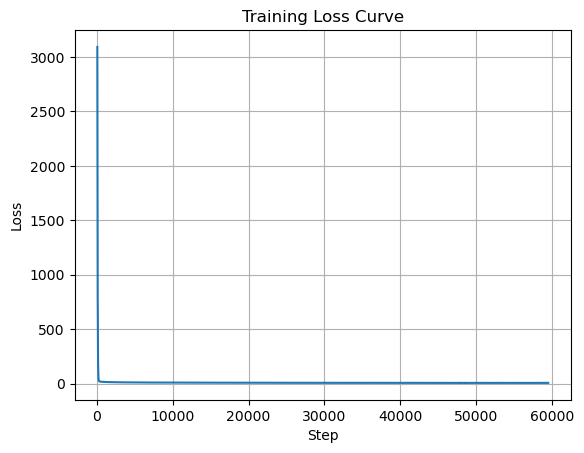

In [34]:
import matplotlib.pyplot as plt

# Sort by step to reconstruct the full training timeline
scalars_df = scalars_df.sort_values("step")

plt.figure()

plt.plot(scalars_df["step"], scalars_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()

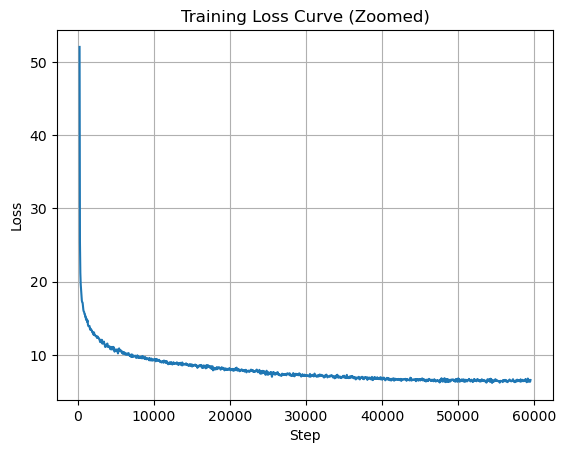

In [35]:
# Sort by step to keep correct order
scalars_df = scalars_df.sort_values("step")

# Filter out very large losses
filtered_df = scalars_df[scalars_df["loss"] < 100]

plt.figure()

plt.plot(filtered_df["step"], filtered_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Zoomed)")

plt.grid()

plt.show()

## List of metrics

In this step, I inspect which validation metrics are present in the scalar records.

In [36]:
# All nuScenes validation metric columns
metrics_cols = [

    # ===================== Car =====================
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_attr_err",

    # ===================== Global Errors =====================
    "NuScenes metric/pred_instances_3d_NuScenes/mATE",
    "NuScenes metric/pred_instances_3d_NuScenes/mASE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAOE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAVE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAAE",

    # ===================== Truck =====================
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err",

    # ===================== Construction Vehicle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err",

    # ===================== Bus =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err",

    # ===================== Trailer =====================
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err",

    # ===================== Barrier =====================
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err",

    # ===================== Motorcycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_attr_err",

    # ===================== Bicycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_attr_err",

    # ===================== Pedestrian =====================
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_attr_err",

    # ===================== Traffic Cone =====================
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_attr_err",

    # ===================== Summary =====================
    "NuScenes metric/pred_instances_3d_NuScenes/NDS",
    "NuScenes metric/pred_instances_3d_NuScenes/mAP",
]

In [37]:
prefix = "NuScenes metric/pred_instances_3d_NuScenes/"

rename_cols = {
    # Summary metrics
    prefix + "NDS": "NDS",
    prefix + "mAP": "mAP",
    prefix + "mATE": "mATE",
    prefix + "mASE": "mASE",
    prefix + "mAOE": "mAOE",
    prefix + "mAVE": "mAVE",
    prefix + "mAAE": "mAAE",
}

classes = [
    "car",
    "truck",
    "construction_vehicle",
    "bus",
    "trailer",
    "barrier",
    "motorcycle",
    "bicycle",
    "pedestrian",
    "traffic_cone",
]

for cls in classes:
    rename_cols[prefix + f"{cls}_AP_dist_0.5"] = f"{cls}_AP_0.5"
    rename_cols[prefix + f"{cls}_AP_dist_1.0"] = f"{cls}_AP_1.0"
    rename_cols[prefix + f"{cls}_AP_dist_2.0"] = f"{cls}_AP_2.0"
    rename_cols[prefix + f"{cls}_AP_dist_4.0"] = f"{cls}_AP_4.0"

    rename_cols[prefix + f"{cls}_trans_err"] = f"{cls}_ATE"
    rename_cols[prefix + f"{cls}_scale_err"] = f"{cls}_ASE"
    rename_cols[prefix + f"{cls}_orient_err"] = f"{cls}_AOE"
    rename_cols[prefix + f"{cls}_vel_err"] = f"{cls}_AVE"
    rename_cols[prefix + f"{cls}_attr_err"] = f"{cls}_AAE"
    
# Keep only metrics + useful identifiers
metrics_df = scalars_df[["run", "epoch", "step"] + metrics_cols].copy()

# Rename columns
metrics_df = metrics_df.rename(columns=rename_cols)

# Keep only validation/evaluation rows
metrics_df = metrics_df.dropna(subset=["NDS", "mAP"]).copy()

print(metrics_df.shape)
metrics_df.head(20)


(10, 100)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,0.9148,0.3421,0.5158,0.3186,1.1485,1.0185,0.3671,0.0396,0.1107,0.1925,0.2368,0.5617,0.2993,0.7311,0.9279,0.4022,0.0000,0.0028,0.0236,0.0382,0.8696,0.4851,1.5369,0.1729,0.3688,0.0661,0.1939,0.3297,0.3863,0.5960,0.2277,1.3168,2.4116,0.6458,0.0002,0.0137,0.0258,0.0696,0.7087,0.2966,1.3437,0.4894,0.2045,0.0619,0.1740,0.2142,0.2607,0.6213,0.3605,0.3225,NaN,NaN,0.0776,0.1373,0.1615,0.1725,0.4113,0.2847,1.4093,1.8322,0.4672,0.0000,0.0000,0.0000,0.0000,0.3787,0.3002,1.3751,0.3335,0.0511,0.3697,0.4879,0.5169,0.5481,0.4015,0.2985,1.5836,1.0658,0.4549,0.1541,0.1675,0.1835,0.2229,0.2801,0.4519,NaN,NaN,NaN,0.278986,0.198266
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,0.7783,0.2748,0.4556,0.2954,0.9540,0.9374,0.3018,0.0835,0.1993,0.2826,0.3239,0.4913,0.2574,0.5045,1.0611,0.4070,0.0000,0.0152,0.0561,0.1069,0.7865,0.4447,1.4301,0.1528,0.3395,0.1227,0.2941,0.4233,0.4492,0.5130,0.1923,0.6533,1.9168,0.5573,0.0111,0.0761,0.1137,0.1600,0.6305,0.2553,1.3726,0.4702,0.2290,0.0924,0.2351,0.2814,0.3258,0.5773,0.3672,0.2476,NaN,NaN,0.1672,0.2311,0.2516,0.2635,0.3381,0.2565,1.0213,1.8372,0.2361,0.0143,0.0172,0.0177,0.0193,0.2845,0.2940,1.3217,0.2937,0.0304,0.4324,0.5530,0.5863,0.6202,0.4063,0.2885,1.5208,0.9890,0.3406,0.2481,0.2644,0.2853,0.3361,0.2574,0.4216,NaN,NaN,NaN,0.337484,0.263817
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,0.6823,0.2316,0.4328,0.2893,0.8433,0.8315,0.2662,0.1090,0.2330,0.3121,0.3537,0.4599,0.2421,0.4180,0.7232,0.3204,0.0004,0.0239,0.0958,0.1474,0.7882,0.4339,1.2817,0.1441,0.3687,0.1552,0.3703,0.5175,0.5706,0.5018,0.1939,0.5497,1.6057,0.4377,0.0188,0.0917,0.1415,0.2004,0.6121,0.2483,1.3081,0.4166,0.1794,0.1593,0.3200,0.3739,0.4115,0.4765,0.3441,0.1931,NaN,NaN,0.1780,0.2347,0.2491,0.2585,0.3076,0.2638,0.8056,1.6662,0.2144,0.0561,0.0662,0.0682,0.0734,0.2746,0.2904,1.1210,0.4522,0.0477,0.4733,0.5725,0.6013,0.6317,0.3803,0.2916,1.5033,0.9616,0.3293,0.3173,0.3401,0.3624,0.4173,0.2579,0.4121,NaN,NaN,NaN,0.386113,0.304838
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,0.6238,0.2273,0.4180,0.2844,0.8277,0.7567,0.2723,0.1434,0.2859,0.3578,0.3986,0.4264,0.2369,0.3954,0.6753,0.3516,0.0000,0.0154,0.0827,0.1762,0.8974,0.4586,1.5577,0.1533,0.3294,0.2361,0.4466,0.5934,0.6412,0.4311,0.1900,0.5164,1.3846,0.4549,0.0426,0.1653,0.2242,0.2880,0.5711,0.2171,1.2549,0.4549,0.2072,0.1857,0.3428,0.4143,0.4577,0.4793,0.3448,0.2380,NaN,NaN,0.2249,0.2922,0.3123,0.3174,0.3009,0.2504,0.7180,1.4437,0.2498,0.0732,0.0813,0.0819,0.0830,0.2592,0.2796,0.9651,0.3965

In [38]:
# Remove last CenterPoint epoch to match BEVFusion,
# since BEVFusion validation did not complete for epoch 10
# metrics_df = metrics_df.iloc[:-1].copy()

**Observations**: 

I’m not seeing a bug with checkpointing or resume, those are working fine. The missing NDS values happen because of the Slurm time limit.

Each epoch runs: training → save checkpoint → validation. Sometimes the job hits the 6-hour limit after training and saving, but before validation finishes. When that happens, the checkpoint exists, but no NDS is logged.

When I resume, training continues normally and validation completes for a later epoch. That’s why I only get NDS for epochs 1, 3, and 5—epochs 2 and 4 were interrupted during validation.

## NDS and mAP

In this step, I plot the NDS (nuScenes Detection Score) over the validation steps. This shows how the model performance improves across epochs. Unlike training loss, this curve reflects actual detection quality on the validation set.

Metrics:
* ```NDS``` (nuScenes Detection Score) is the main benchmark metric that combines detection accuracy and prediction quality into a single score. It includes mAP together with five true-positive metrics: translation error (mATE), scale error (mASE), orientation error (mAOE), velocity error (mAVE), and attribute error (mAAE). While mAP measures whether objects are detected and approximately localized, NDS additionally evaluates how accurate the predicted 3D box position, size, orientation, motion, and semantic attributes are.
* nuScenes ```mAP``` measures how well a model detects objects across different localization accuracies. A prediction is considered correct if the predicted object center is within one of four distance thresholds (0.5m, 1m, 2m, 4m) from the ground-truth center on the ground plane. AP is computed for each class and threshold, and the final mAP is the average over all classes and thresholds. Using multiple thresholds allows nuScenes to evaluate both object detection capability and localization precision.

**Source**: https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/eval/detection/README.md



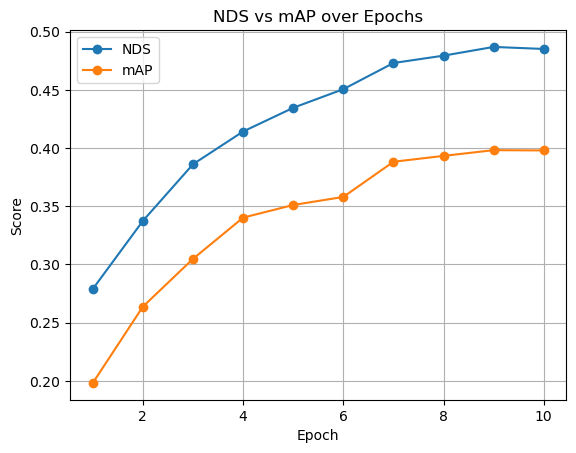

In [39]:
# Plot both curves
plt.plot(metrics_df["step"], metrics_df["NDS"], marker="o", label="NDS")
plt.plot(metrics_df["step"], metrics_df["mAP"], marker="o", label="mAP")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("NDS vs mAP over Epochs")

plt.legend()
plt.grid()

plt.show()

**Observations:** Both NDS and mAP increase steadily across all training epochs, indicating continuous improvement of the LiDAR-only baseline during training. The strongest gains occur during the first epochs, while the improvement rate becomes more gradual afterward. Unlike the BEVFusion experiment, no clear plateau is observed within the first 5 epochs, suggesting that the model may still benefit from additional training epochs.

## Global errors
* ```mATE``` (mean Average Translation Error) measures the average localization error between the predicted and ground-truth object centers on the ground plane, in meters. Lower values indicate more accurate object positioning.
* ```mASE``` (mean Average Scale Error) measures the error in predicted object size using 1 − IoU after aligning translation and orientation. Lower values indicate more accurate object dimensions.
* ```mAOE``` (mean Average Orientation Error) measures the average difference in yaw angle between predicted and ground-truth bounding boxes, in radians. Lower values indicate more accurate orientation estimation.
* ```mAVE``` (mean Average Velocity Error) measures the average error in predicted object velocity, computed as the L2 distance between predicted and ground-truth velocities in m/s. Lower values indicate more accurate motion estimation.
* ```mAAE``` (mean Average Attribute Error) measures the error in semantic attribute prediction, defined as 1 − attribute classification accuracy. Lower values indicate better attribute prediction (e.g., moving, parked, standing).

**Source:** https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html

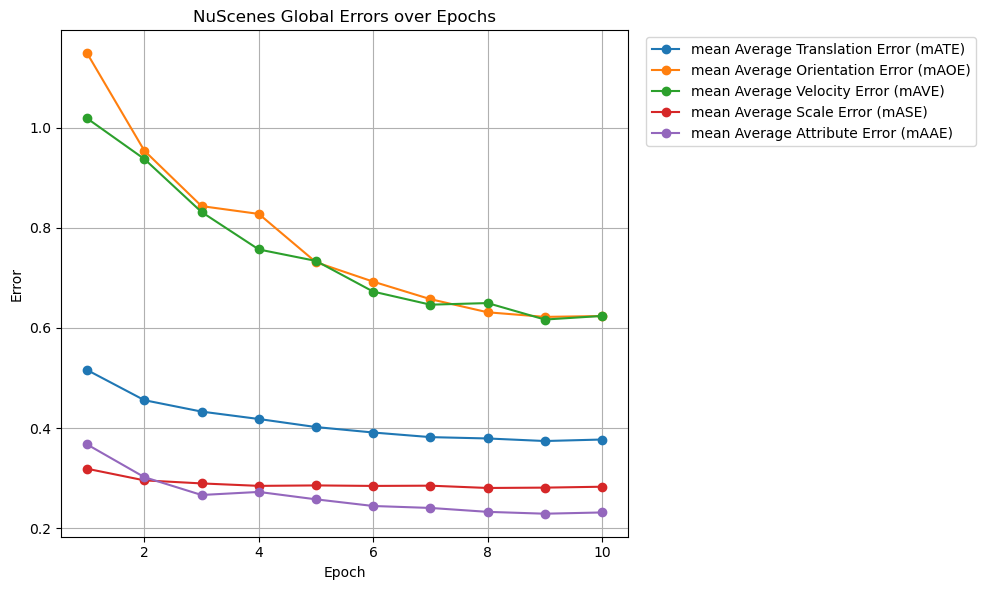

In [40]:
plt.figure(figsize=(10, 6))

# Plot curves
plt.plot(metrics_df["step"], metrics_df["mATE"], marker="o",
         label="mean Average Translation Error (mATE)")

plt.plot(metrics_df["step"], metrics_df["mAOE"], marker="o",
         label="mean Average Orientation Error (mAOE)")

plt.plot(metrics_df["step"], metrics_df["mAVE"], marker="o",
         label="mean Average Velocity Error (mAVE)")

plt.plot(metrics_df["step"], metrics_df["mASE"], marker="o",
         label="mean Average Scale Error (mASE)")

plt.plot(metrics_df["step"], metrics_df["mAAE"], marker="o",
         label="mean Average Attribute Error (mAAE)")

# Labels
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("NuScenes Global Errors over Epochs")

# Put legend outside
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid()

# Prevent clipping
plt.tight_layout()

plt.show()

In [41]:
last_row = metrics_df.iloc[-1]

print("Global detection metrics:")
print(f"NuScenes Detection Score (NDS)       : {last_row['NDS']:.4f}")
print(f"mean Average Precision (mAP)         : {last_row['mAP']:.4f}")

print("\nGlobal error metrics:")
print(f"mean Average Translation Error (mATE): {last_row['mATE']:.4f}")
print(f"mean Average Scale Error (mASE)      : {last_row['mASE']:.4f}")
print(f"mean Average Orientation Error (mAOE): {last_row['mAOE']:.4f}")
print(f"mean Average Velocity Error (mAVE)   : {last_row['mAVE']:.4f}")
print(f"mean Average Attribute Error (mAAE)  : {last_row['mAAE']:.4f}")


Global detection metrics:
NuScenes Detection Score (NDS)       : 0.4851
mean Average Precision (mAP)         : 0.3980

Global error metrics:
mean Average Translation Error (mATE): 0.3770
mean Average Scale Error (mASE)      : 0.2827
mean Average Orientation Error (mAOE): 0.6237
mean Average Velocity Error (mAVE)   : 0.6239
mean Average Attribute Error (mAAE)  : 0.2313


**Observations:** Most error metrics decrease steadily during training, showing improved detection performance over epochs. The largest improvements occur during the first epochs, while the curves become more stable after epoch 3. Orientation and velocity errors (mAOE and mAVE) show the strongest improvements, whereas scale error (mASE) changes only slightly during training.

In [42]:
metrics_df.head(10)

,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,0.9148,0.3421,0.5158,0.3186,1.1485,1.0185,0.3671,0.0396,0.1107,0.1925,0.2368,0.5617,0.2993,0.7311,0.9279,0.4022,0.0000,0.0028,0.0236,0.0382,0.8696,0.4851,1.5369,0.1729,0.3688,0.0661,0.1939,0.3297,0.3863,0.5960,0.2277,1.3168,2.4116,0.6458,0.0002,0.0137,0.0258,0.0696,0.7087,0.2966,1.3437,0.4894,0.2045,0.0619,0.1740,0.2142,0.2607,0.6213,0.3605,0.3225,NaN,NaN,0.0776,0.1373,0.1615,0.1725,0.4113,0.2847,1.4093,1.8322,0.4672,0.0000,0.0000,0.0000,0.0000,0.3787,0.3002,1.3751,0.3335,0.0511,0.3697,0.4879,0.5169,0.5481,0.4015,0.2985,1.5836,1.0658,0.4549,0.1541,0.1675,0.1835,0.2229,0.2801,0.4519,NaN,NaN,NaN,0.278986,0.198266
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,0.7783,0.2748,0.4556,0.2954,0.9540,0.9374,0.3018,0.0835,0.1993,0.2826,0.3239,0.4913,0.2574,0.5045,1.0611,0.4070,0.0000,0.0152,0.0561,0.1069,0.7865,0.4447,1.4301,0.1528,0.3395,0.1227,0.2941,0.4233,0.4492,0.5130,0.1923,0.6533,1.9168,0.5573,0.0111,0.0761,0.1137,0.1600,0.6305,0.2553,1.3726,0.4702,0.2290,0.0924,0.2351,0.2814,0.3258,0.5773,0.3672,0.2476,NaN,NaN,0.1672,0.2311,0.2516,0.2635,0.3381,0.2565,1.0213,1.8372,0.2361,0.0143,0.0172,0.0177,0.0193,0.2845,0.2940,1.3217,0.2937,0.0304,0.4324,0.5530,0.5863,0.6202,0.4063,0.2885,1.5208,0.9890,0.3406,0.2481,0.2644,0.2853,0.3361,0.2574,0.4216,NaN,NaN,NaN,0.337484,0.263817
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,0.6823,0.2316,0.4328,0.2893,0.8433,0.8315,0.2662,0.1090,0.2330,0.3121,0.3537,0.4599,0.2421,0.4180,0.7232,0.3204,0.0004,0.0239,0.0958,0.1474,0.7882,0.4339,1.2817,0.1441,0.3687,0.1552,0.3703,0.5175,0.5706,0.5018,0.1939,0.5497,1.6057,0.4377,0.0188,0.0917,0.1415,0.2004,0.6121,0.2483,1.3081,0.4166,0.1794,0.1593,0.3200,0.3739,0.4115,0.4765,0.3441,0.1931,NaN,NaN,0.1780,0.2347,0.2491,0.2585,0.3076,0.2638,0.8056,1.6662,0.2144,0.0561,0.0662,0.0682,0.0734,0.2746,0.2904,1.1210,0.4522,0.0477,0.4733,0.5725,0.6013,0.6317,0.3803,0.2916,1.5033,0.9616,0.3293,0.3173,0.3401,0.3624,0.4173,0.2579,0.4121,NaN,NaN,NaN,0.386113,0.304838
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,0.6238,0.2273,0.4180,0.2844,0.8277,0.7567,0.2723,0.1434,0.2859,0.3578,0.3986,0.4264,0.2369,0.3954,0.6753,0.3516,0.0000,0.0154,0.0827,0.1762,0.8974,0.4586,1.5577,0.1533,0.3294,0.2361,0.4466,0.5934,0.6412,0.4311,0.1900,0.5164,1.3846,0.4549,0.0426,0.1653,0.2242,0.2880,0.5711,0.2171,1.2549,0.4549,0.2072,0.1857,0.3428,0.4143,0.4577,0.4793,0.3448,0.2380,NaN,NaN,0.2249,0.2922,0.3123,0.3174,0.3009,0.2504,0.7180,1.4437,0.2498,0.0732,0.0813,0.0819,0.0830,0.2592,0.2796,0.9651,0.3965

In [43]:
classes = [
    "car", "truck", "bus", "trailer", "construction_vehicle",
    "pedestrian", "motorcycle", "bicycle", "traffic_cone", "barrier"
]

last = metrics_df.iloc[-1]

per_class_df = pd.DataFrame(index=classes)

# Average Precision
per_class_df["Average Precision (AP)"] = [
    last[[f"{cls}_AP_0.5", f"{cls}_AP_1.0", f"{cls}_AP_2.0", f"{cls}_AP_4.0"]].mean()
    for cls in classes
]

# Error metrics
per_class_df["Translation Error (ATE)"] = [last[f"{cls}_ATE"] for cls in classes]
per_class_df["Scale Error (ASE)"] = [last[f"{cls}_ASE"] for cls in classes]
per_class_df["Orientation Error (AOE)"] = [last[f"{cls}_AOE"] for cls in classes]
per_class_df["Velocity Error (AVE)"] = [last[f"{cls}_AVE"] for cls in classes]
per_class_df["Attribute Error (AAE)"] = [last[f"{cls}_AAE"] for cls in classes]

per_class_df = per_class_df.round(3)

per_class_df = per_class_df.sort_values(
    by="Average Precision (AP)",
    ascending=False
)

per_class_df

,Average Precision (AP),Translation Error (ATE),Scale Error (ASE),Orientation Error (AOE),Velocity Error (AVE),Attribute Error (AAE)
car,0.747,0.234,0.166,0.275,0.551,0.219
pedestrian,0.703,0.257,0.291,0.958,0.594,0.232
bus,0.554,0.393,0.187,0.224,1.352,0.392
traffic_cone,0.426,0.230,0.401,NaN,NaN,NaN
truck,0.378,0.396,0.218,0.318,0.482,0.282
motorcycle,0.372,0.261,0.254,0.540,1.075,0.235
barrier,0.351,0.408,0.335,0.194,NaN,NaN
trailer,0.178,0.558,0.235,1.125,0.442,0.136
bicycle,0.172,0.232,0.280,0.742,0.338,0.022
construction_vehicle,0.099,0.801,0.460,1.237,0.157,0.334


**Observations:** Detection performance varies across object classes, with cars and pedestrians achieving the highest Average Precision (AP) values among the main dynamic objects. Construction vehicles, bicycles, and trailers remain the most difficult classes to detect, showing lower AP and higher translation error (ATE) and orientation error (AOE). Velocity error (AVE) is particularly high for buses and motorcycles, indicating more difficulty in motion estimation for these classes. Traffic cones and barriers do not include orientation, velocity, or attribute metrics because these properties are not defined for these object types in the nuScenes evaluation.

# Export data

In [44]:
# Export cleaned metrics for final comparison notebook

OUTPUT_DIR: Final[Path] = (
    PROJECT_ROOT / "results" / "final_metrics"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Add experiment metadata
metrics_df["model"] = CONFIG["model_name"]
metrics_df["subset"] = CONFIG["subset_label"]
metrics_df["experiment_name"] = CONFIG["experiment_name"]
metrics_df["gpu_type"] = CONFIG["gpu_type"]
metrics_df["max_epochs"] = CONFIG["max_epochs"]

# Output file
OUTPUT_FILE: Final[Path] = (
    OUTPUT_DIR /
    f"{CONFIG['experiment_name']}_metrics.csv"
)

# Save cleaned metrics
metrics_df.to_csv(OUTPUT_FILE, index=False)

print("Saved metrics dataframe:")
print(OUTPUT_FILE)

Saved metrics dataframe:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/results/final_metrics/centerpoint_nuscenes_20pct_10ep_run1_metrics.csv
